# RAKSHAK — Exploratory Data Analysis (CICIDS2017)

Working notebook for `data/processed/cicids_clean.parquet`, produced by `src/preprocess.py`: labels mapped to the 5 unified classes, inf/NaN rows dropped, constant columns removed. **Not yet scaled** — scaling is deliberately deferred until after the train/test split (see the data-leakage discussion in `preprocess.py`'s `main()` docstring), so the values you see here are still in their original, interpretable units.

Goals for this notebook (instructions.md Step 4):
1. Sanity-check the loaded data
2. Class distribution
3. Correlation heatmap of the top 30 features
4. Box plots of the top 5 features by class
5. Class imbalance observations, to inform the SMOTE strategy later

## 1. Load and sanity-check the data

Confirm the parquet round-tripped correctly: right row count, `Label` still a string, and the numeric feature columns still numeric.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Notebooks have no __file__, unlike preprocess.py, so PROJECT_ROOT can't be
# computed the same way. Jupyter's working directory in VS Code is usually
# the workspace root, but can sometimes be notebooks/ itself — handle both.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CICIDS_PATH = PROJECT_ROOT / "data" / "processed" / "cicids_clean.parquet"

df = pd.read_parquet(CICIDS_PATH)

print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
df.head()

Shape: (2827876, 71)

Dtypes:
Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
Idle Std                       float64
Idle Max                         int64
Idle Min                         int64
Label                              str
Length: 71, dtype: object


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Normal
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Normal
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Normal
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Normal
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Normal


## 2. Class distribution

Visualizing the imbalance we already measured numerically — this is the plot that justifies applying SMOTE later.

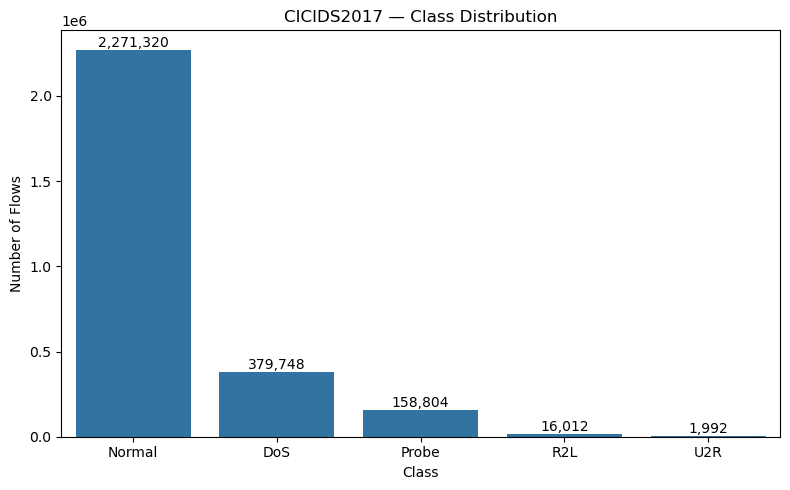

Label
Normal    2271320
DoS        379748
Probe      158804
R2L         16012
U2R          1992
Name: count, dtype: int64

In [2]:
label_counts = df["Label"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, ax=ax)
ax.set_title("CICIDS2017 — Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Flows")
for i, count in enumerate(label_counts.values):
    ax.text(i, count, f"{count:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

label_counts

**Observations:** *(rewrite in your own words)*

- Normal: 2,271,320 · DoS: 379,748 · Probe: 158,804 · R2L: 16,012 · U2R: 1,992
- Normal outnumbers U2R by roughly 1,140:1 — a model could hit high accuracy while never once predicting U2R correctly. Accuracy alone will be a misleading metric here; per-class F1/recall matters more.

## 3. Correlation heatmap (top 30 features)

71 columns is too many for a readable heatmap, so we rank features by their absolute correlation with a numeric-encoded `Label` and take the top 30. This surfaces two things: which features look most related to attack type, and which pairs of features are highly correlated *with each other* (redundant, candidates for dropping in Phase 3).

Caveat: correlation only captures *linear* relationships. A feature can be highly predictive in a nonlinear way and still show near-zero correlation here — this is a first-pass signal, not the final word. Real feature importance comes from Phase 3's trained Random Forest.

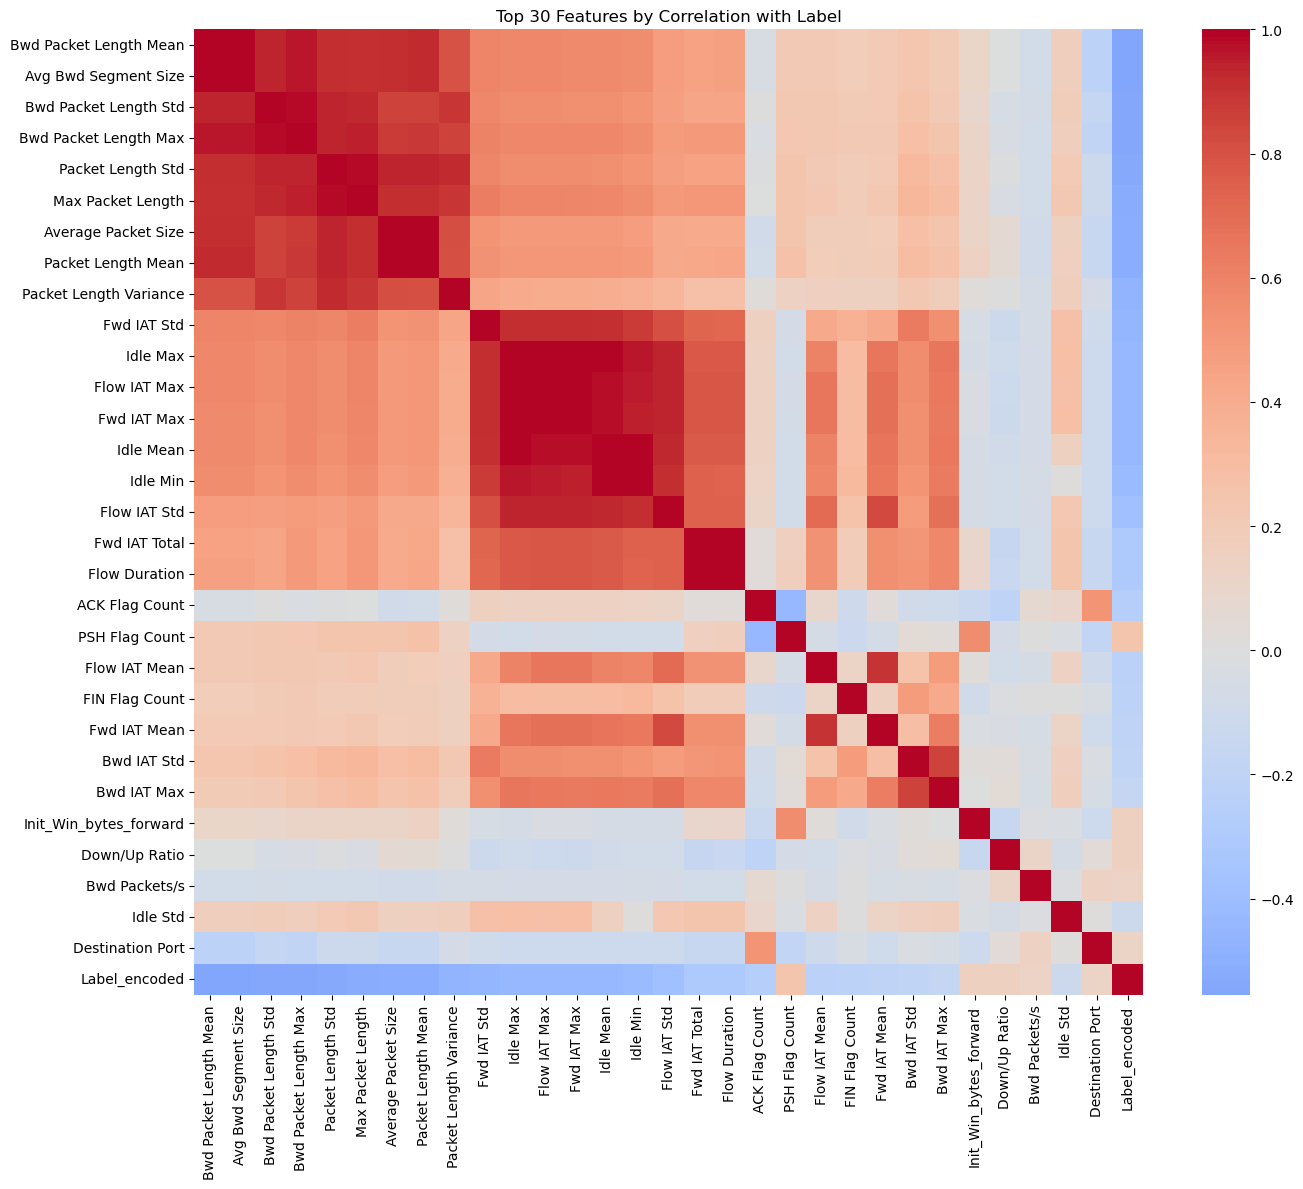

In [3]:
from sklearn.preprocessing import LabelEncoder

# Throwaway encoder for this plot only - NOT saved, unlike the encoders in
# preprocess.py. We just need Label as a number to compute correlations.
label_encoded = LabelEncoder().fit_transform(df["Label"])

numeric_df = df.drop(columns=["Label"]).select_dtypes(include="number").copy()
numeric_df["Label_encoded"] = label_encoded

correlations = numeric_df.corr()["Label_encoded"].drop("Label_encoded")
top_30_features = correlations.abs().sort_values(ascending=False).head(30).index.tolist()

corr_matrix = numeric_df[top_30_features + ["Label_encoded"]].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Top 30 Features by Correlation with Label")
plt.tight_layout()
plt.show()

**Observations:** *(rewrite in your own words)*

- Top correlated features are dominated by two families: packet-size stats (`Bwd Packet Length *`, `Packet Length *`, `Average Packet Size`) and timing stats (`Fwd IAT Std/Max`, `Idle Max/Mean/Min`, `Flow IAT Max`).
- `Bwd Packet Length Mean` and `Avg Bwd Segment Size` correlate identically (-0.5550 to 4dp) — almost certainly the same underlying CICFlowMeter calculation under two names. Candidate to drop one in Phase 3 feature selection.
- Caveat: correlation was computed against `Label` label-encoded alphabetically (DoS=0...U2R=4), which is an arbitrary ordering for a 5-class problem — treat this ranking as a first-pass signal, not ground truth. Real feature importance comes from Phase 3's trained Random Forest.

## 4. Box plots — top 5 features by class

Reusing the correlation ranking from Section 3 to pick the 5 features most linked to `Label`, then checking whether their distributions actually separate the five classes visually.

`showfliers=False` hides extreme outliers — network flow data has some very extreme values (e.g. a flow duration of several minutes next to most flows lasting milliseconds), and showing every outlier would squash the boxes themselves into an unreadable sliver at the bottom of the plot.

Top 5 features by |correlation| with Label: ['Bwd Packet Length Mean', 'Avg Bwd Segment Size', 'Bwd Packet Length Std', 'Bwd Packet Length Max', 'Packet Length Std']


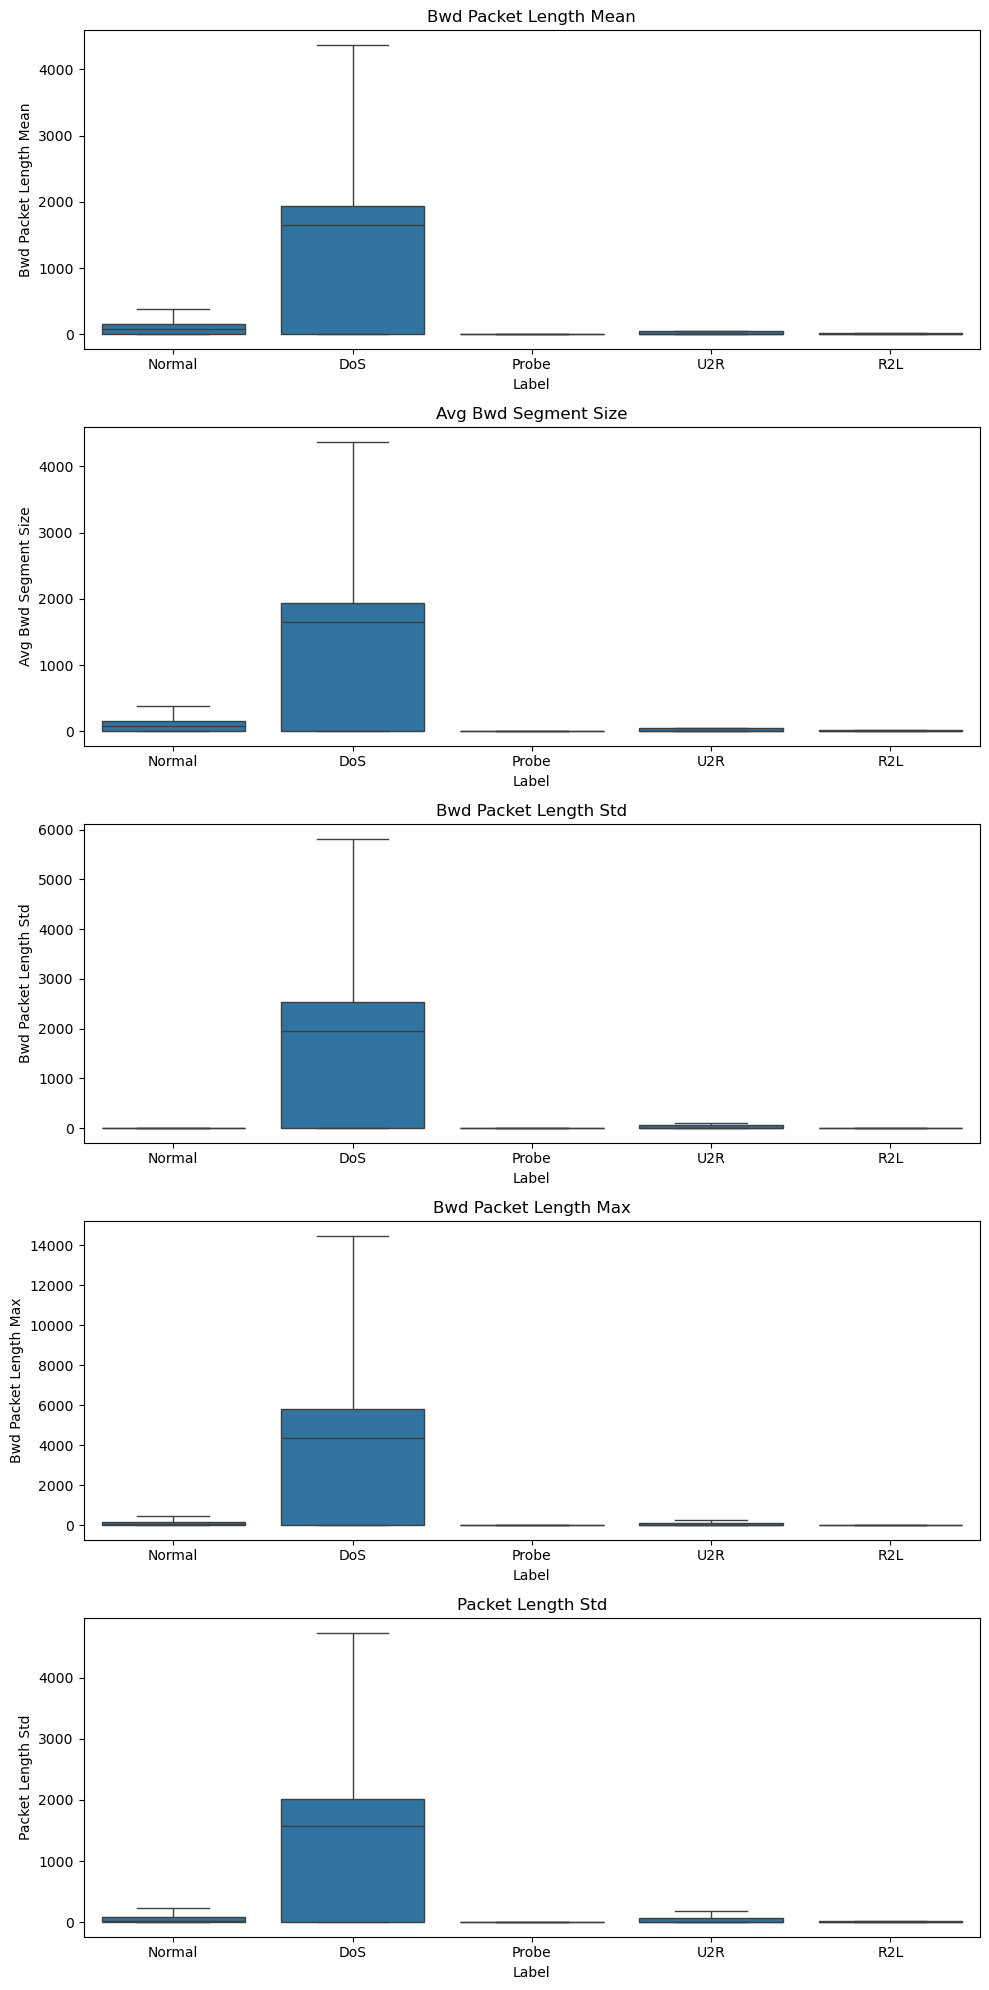

In [4]:
top_5_features = correlations.abs().sort_values(ascending=False).head(5).index.tolist()
print("Top 5 features by |correlation| with Label:", top_5_features)

fig, axes = plt.subplots(nrows=len(top_5_features), ncols=1, figsize=(10, 4 * len(top_5_features)))
for ax, feature in zip(axes, top_5_features):
    sns.boxplot(data=df, x="Label", y=feature, ax=ax, showfliers=False)
    ax.set_title(feature)
plt.tight_layout()
plt.show()

**Observations:** *(rewrite in your own words — look at the actual plot to confirm or refute this)*

- All 5 top features are backward-packet-size stats (2 of them near-duplicates, see Section 3). Hypothesis to check against the plot: many DoS attacks are one-directional floods — attacker sends heavily, victim barely responds — so backward packet size may collapse toward zero for DoS while Normal's two-way traffic keeps it higher. Confirm whether DoS's box actually sits near zero compared to Normal's in the rendered plot.

## 5. Class imbalance summary

*(rewrite in your own words)*

U2R (1,992 rows, 0.07% of the dataset) and R2L (16,012 rows, 0.57%) are severely underrepresented next to Normal (2,271,320) and DoS (379,748). This motivates applying SMOTE in Phase 3 — but only to the training split, fit after the train/test split, never to the test set. The test set has to keep the real-world class frequencies, or evaluation results won't reflect how the model performs on genuine, naturally-imbalanced traffic.